In [108]:
## build a basic chatbot using Langgraph(Graph API)
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



In [109]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
# graph_builder = StateGraph(State)
# graph_builder

In [110]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [111]:
from langchain_groq import ChatGroq
# from langchain_classic.chat_model import init_chat_model
# llm=init_chat_model("groq:llama-3.1-8b-instant")
llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10f338050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f338950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [112]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [113]:
graph_builder=StateGraph(State)

##adding node
graph_builder.add_node("llmchatbot", chatbot)

## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph=graph_builder.compile()

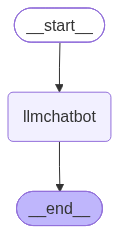

In [114]:
## visualise how the graph looks 
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [115]:
response=graph.invoke({"messages": "Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='c0956f3b-f1d6-48b5-a0dd-c1fbe823b555'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006786378, 'completion_tokens_details': None, 'prompt_time': 0.00248148, 'prompt_tokens_details': None, 'queue_time': 0.04902594, 'total_time': 0.009267858}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9585-c674-7e90-a7c2-588263361eff-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}

In [116]:
response["messages"][-1].content

'How can I assist you today?'

In [118]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you have. How can I assist you today?


In [119]:
## Chatbot with tool
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool

TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [120]:
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the naviga

In [121]:
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [122]:
tools=[tool, multiply]

In [124]:
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10f338050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f338950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized fo

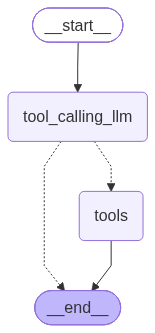

In [129]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
## Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}

## adding nodes and Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## adding edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## compile the graph
graph = builder.compile()

## creating image of the graph
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [131]:
response=graph.invoke({"messages":"What is the recent ai news"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/07/23/open-ai-hugging-face-hack-kill-switch-bill-congress.html", "title": "OpenAI\'s Hugging Face hack triggers \'AI Kill Switch\' bill in Congress - CNBC", "score": 0.6010557, "published_date": "Thu, 23 Jul 2026 19:51:08 GMT", "content": "# OpenAI\'s Hugging Face hack triggers \'AI Kill Switch\' bill in Congress. * Rep. Ted Lieu, D-Calif., and Rep. Nathaniel Moran, R-Texas, on Thursday introduced a bill called the \\"AI Kill Switch Act.\\". * The bill would require AI companies to maintain the ability to shut down, throttle or suspend their models. Rep. Ted Lieu, D-Calif., and Rep. Nathaniel Moran, R-Texas, on Thursday introduced a bill called the \\"AI Kill Switch Act,\\" which would require artificial intelligence companies to maintain the ability to shut down, throttle or suspend their models. \\"It is imperative that these AI systems have kill swit

In [132]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nm3g067dx)
 Call ID: nm3g067dx
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/07/23/open-ai-hugging-face-hack-kill-switch-bill-congress.html", "title": "OpenAI's Hugging Face hack triggers 'AI Kill Switch' bill in Congress - CNBC", "score": 0.6010557, "published_date": "Thu, 23 Jul 2026 19:51:08 GMT", "content": "# OpenAI's Hugging Face hack triggers 'AI Kill Switch' bill in Congress. * Rep. Ted Lieu, D-Calif., and Rep. Nathaniel Moran, R-Texas, on Thursday introduced a bill called the \"AI Kill Switch Act.\". * The 

In [133]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (jb3tf4vex)
 Call ID: jb3tf4vex
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


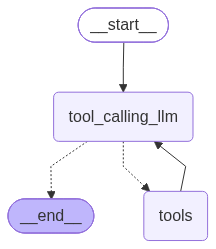

In [134]:
## ReACT Agent
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [135]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3vkx0sdfj)
 Call ID: 3vkx0sdfj
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (7p1xme34h)
 Call ID: 7p1xme34h
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/07/23/open-ai-hugging-face-hack-kill-switch-bill-congress.html", "title": "OpenAI's Hugging Face hack triggers 'AI Kill Switch' bill in Congress - CNBC", "score": 0.6010557, "published_date": "Thu, 23 Jul 2026 19:51:08 GMT", "content": "# OpenAI's Hugging Face hack triggers 'AI Kill Switch' bill in Congress. * Rep. Ted Lieu, D-Calif., and Rep. Na

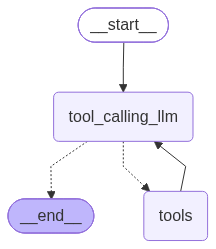

In [136]:
## Adding memory in Agentic Graph
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [138]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": "Hi, my name is Sachi and I work as an AI Engineer"}, config=config)
response["messages"][-1].content

'Nice to meet you, Sachi.'

In [139]:
response = graph.invoke({"messages": "What is my name and how I work"}, config=config)
response["messages"][-1].content

"Based on the search results, it appears that there are multiple individuals named Sachi working in the field of AI, but I couldn't find any information confirming that the Sachi in the search result is the same person as you. If you'd like to confirm your identity, you may want to try searching again with more specific keywords."

In [141]:
## Streaming
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [142]:
## creating simple graph for streaming
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

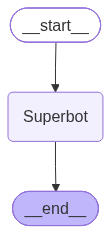

In [143]:
builder = StateGraph(State)

##Node
builder.add_node("Superbot", superbot)

##edges
builder.add_edge(START, "Superbot")
builder.add_edge("Superbot", END)

##compile the graph
graph_builder = builder.compile(checkpointer=memory)

## creating the image
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))



In [144]:
config = {"configurable": {"thread_id": "2"}}
for chunk in graph_builder.stream({"messages": "Hi, my name is Sachi and I like frooti"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Sachi. Frooti is a popular fruit drink in India, made by Parle Agro. It's known for its sweet and tangy taste, and comes in a variety of fruit flavors. Which is your favorite flavor of Frooti?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 48, 'total_tokens': 105, 'completion_time': 0.112660835, 'completion_tokens_details': None, 'prompt_time': 0.002280372, 'prompt_tokens_details': None, 'queue_time': 0.052620017, 'total_time': 0.114941207}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f98f6-bffa-7882-957f-d670d6ab6a71-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 57, 'total_tokens': 105})]}}


In [145]:
config = {"configurable": {"thread_id": "2"}}
for chunk in graph_builder.stream({"messages": "Hi, my name is Sachi and I like frooti"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Sachi and I like frooti', additional_kwargs={}, response_metadata={}, id='aa579c3c-9f4c-47e0-af15-aa133d83f700'), AIMessage(content="Nice to meet you, Sachi. Frooti is a popular fruit drink in India, made by Parle Agro. It's known for its sweet and tangy taste, and comes in a variety of fruit flavors. Which is your favorite flavor of Frooti?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 48, 'total_tokens': 105, 'completion_time': 0.112660835, 'completion_tokens_details': None, 'prompt_time': 0.002280372, 'prompt_tokens_details': None, 'queue_time': 0.052620017, 'total_time': 0.114941207}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f98f6-bffa-7882-957f-d670d6ab6a71-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [146]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages": "Hi, my name is Sachi and I like frooti"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hello Sachi. Frooti is a popular Indian fruit drink made from real fruit pulp. It's known for its unique taste and comes in various flavors. Which flavor of Frooti is your favorite?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 48, 'total_tokens': 91, 'completion_time': 0.081918927, 'completion_tokens_details': None, 'prompt_time': 0.003556577, 'prompt_tokens_details': None, 'queue_time': 0.050881872, 'total_time': 0.085475504}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f98f7-a5db-75e3-a0a2-96885f4666d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 43, 'total_tokens': 91})]}}


In [147]:
for chunk in graph_builder.stream({"messages": "I also like maaza"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Sachi and I like frooti', additional_kwargs={}, response_metadata={}, id='4b416dc4-6bf3-4038-bc75-f53a8324ecae'), AIMessage(content="Hello Sachi. Frooti is a popular Indian fruit drink made from real fruit pulp. It's known for its unique taste and comes in various flavors. Which flavor of Frooti is your favorite?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 48, 'total_tokens': 91, 'completion_time': 0.081918927, 'completion_tokens_details': None, 'prompt_time': 0.003556577, 'prompt_tokens_details': None, 'queue_time': 0.050881872, 'total_time': 0.085475504}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f98f7-a5db-75e3-a0a2-96885f4666d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 43, 'tot

In [148]:
config = {"configurable": {"thread_id": "4"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Sachi and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Sachi and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f98f8-ab79-75a2-93db-1ca213e4de87', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Sachi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='945810f4-f76d-49d5-9b26-0d7f24be4fb0')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019f98f8-aba7-7071-b0dd-8e0776b48682', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:3a915bea-95a3-ad28-d95f-78a78a41f1d8'}, 'parent_ids': ['019f98f8-ab79-75a2-93db-1ca213e4de87']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':